##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

IMAGE_DIR = "/content/drive/MyDrive/lab5_cv"
image_paths = [os.path.join(IMAGE_DIR, f) for f in os.listdir(IMAGE_DIR) if f.endswith((".jpg", ".png"))]
image_paths.sort()  # optional, to keep consistent order
print("Found images:", image_paths)

Found images: ['/content/drive/MyDrive/lab5_cv/e.png', '/content/drive/MyDrive/lab5_cv/tablewithchairs.png', '/content/drive/MyDrive/lab5_cv/threebirds.png', '/content/drive/MyDrive/lab5_cv/twocars.png', '/content/drive/MyDrive/lab5_cv/w.png']


In [3]:
# If needed (run once)
!pip install -q tensorflow tensorflow-hub opencv-python matplotlib pillow

In [9]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import tensorflow_hub as hub
from kagglehub import model_download

In [5]:
COCO_LABELS = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
    11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench',
    16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep',
    21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe',
    27: 'backpack', 28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase',
    34: 'frisbee', 35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite',
    39: 'baseball bat', 40: 'baseball glove', 41: 'skateboard', 42: 'surfboard',
    43: 'tennis racket', 44: 'bottle', 46: 'wine glass', 47: 'cup',
    48: 'fork', 49: 'knife', 50: 'spoon', 51: 'bowl', 52: 'banana',
    53: 'apple', 54: 'sandwich', 55: 'orange', 56: 'broccoli', 57: 'carrot',
    58: 'hot dog', 59: 'pizza', 60: 'donut', 61: 'cake', 62: 'chair',
    63: 'couch', 64: 'potted plant', 65: 'bed', 67: 'dining table',
    70: 'toilet', 72: 'tv', 73: 'laptop', 74: 'mouse', 75: 'remote',
    76: 'keyboard', 77: 'cell phone', 78: 'microwave', 79: 'oven',
    80: 'toaster', 81: 'sink', 82: 'refrigerator', 84: 'book', 85: 'clock',
    86: 'vase', 87: 'scissors', 88: 'teddy bear', 89: 'hair drier', 90: 'toothbrush'
}

In [6]:
IMAGE_DIR = "/content/drive/MyDrive/lab5_cv"
image_paths = [
    os.path.join(IMAGE_DIR, "/content/drive/MyDrive/lab5_cv/tablewithchairs.png"),
    os.path.join(IMAGE_DIR, "/content/drive/MyDrive/lab5_cv/threebirds.png"),
    os.path.join(IMAGE_DIR, "/content/drive/MyDrive/lab5_cv/twocars.png"),
    os.path.join(IMAGE_DIR, "/content/drive/MyDrive/lab5_cv/w.png"),
    os.path.join(IMAGE_DIR, "/content/drive/MyDrive/lab5_cv/e.png"),
]

In [7]:
def load_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)
    return image_np

In [16]:
# Download model from Kaggle
model_path = model_download("tensorflow/mask-rcnn-inception-resnet-v2/tensorFlow2/1024x1024")
print("Model downloaded at:", model_path)

# Load the Mask R-CNN model
detector = tf.saved_model.load(model_path)
print("Mask R-CNN model loaded successfully!")

Model downloaded at: /kaggle/input/mask-rcnn-inception-resnet-v2/tensorflow2/1024x1024/1
Mask R-CNN model loaded successfully!


In [17]:
def run_inference(image_np):
    # Convert to tensor and add batch dimension
    input_tensor = tf.convert_to_tensor(image_np, dtype=tf.uint8)
    input_tensor = tf.expand_dims(input_tensor, axis=0)  # [1, H, W, 3]

    # Run model
    outputs = detector(input_tensor)

    # Convert outputs to numpy
    results = {key: value.numpy() for key, value in outputs.items()}
    return results

In [18]:
def random_color():
    return np.random.randint(0, 255, size=3).tolist()

In [19]:
def visualize_predictions(image_np, results, score_threshold=0.5, mask_threshold=0.5):
    image_vis = image_np.copy()
    h, w, _ = image_vis.shape

    # Model outputs
    detection_scores = results['detection_scores'][0]
    detection_boxes = results['detection_boxes'][0]          # normalized [ymin, xmin, ymax, xmax]
    detection_classes = results['detection_classes'][0].astype(np.int32)
    detection_masks = results['detection_masks'][0]          # [N, mask_h, mask_w]

    num_detections = len(detection_scores)

    for i in range(num_detections):
        score = detection_scores[i]

        if score < score_threshold:
            continue

        class_id = detection_classes[i]
        label = COCO_LABELS.get(class_id, f"class_{class_id}")
        box = detection_boxes[i]
        mask = detection_masks[i]

        # Convert normalized box to pixel coords
        ymin, xmin, ymax, xmax = box
        y1, x1 = int(ymin * h), int(xmin * w)
        y2, x2 = int(ymax * h), int(xmax * w)

        # Safety clamp
        y1, x1 = max(0, y1), max(0, x1)
        y2, x2 = min(h, y2), min(w, x2)

        if y2 <= y1 or x2 <= x1:
            continue

        color = random_color()

        # Resize mask to box size
        mask_resized = cv2.resize(mask, (x2 - x1, y2 - y1))
        mask_binary = (mask_resized > mask_threshold).astype(np.uint8)

        # Apply mask overlay
        roi = image_vis[y1:y2, x1:x2]
        colored_mask = np.zeros_like(roi, dtype=np.uint8)
        colored_mask[:, :] = color

        alpha = 0.5
        roi[mask_binary == 1] = cv2.addWeighted(
            roi[mask_binary == 1], 1 - alpha,
            colored_mask[mask_binary == 1], alpha,
            0
        )

        image_vis[y1:y2, x1:x2] = roi

        # Draw bounding box
        cv2.rectangle(image_vis, (x1, y1), (x2, y2), color, 2)

        # Label text
        text = f"{label}: {score:.2f}"
        text_y = max(y1 - 10, 20)
        cv2.putText(
            image_vis, text, (x1, text_y),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA
        )

    return image_vis

In [20]:
def extract_predictions(results, score_threshold=0.5):
    detections = []

    scores = results['detection_scores'][0]
    boxes = results['detection_boxes'][0]
    classes = results['detection_classes'][0].astype(np.int32)
    masks = results['detection_masks'][0]

    for i in range(len(scores)):
        if scores[i] < score_threshold:
            continue

        class_id = classes[i]
        label = COCO_LABELS.get(class_id, f"class_{class_id}")

        detections.append({
            "index": i,
            "class_id": class_id,
            "class_name": label,
            "score": float(scores[i]),
            "box_normalized": boxes[i].tolist(),   # [ymin, xmin, ymax, xmax]
            "mask_shape": masks[i].shape           # mask array exists here
        })

    return detections

In [21]:
all_results = {}

for path in image_paths:
    print(f"\nProcessing: {path}")
    image_np = load_image(path)
    results = run_inference(image_np)
    all_results[path] = {
        "image": image_np,
        "results": results
    }

    detections = extract_predictions(results, score_threshold=0.5)
    print(f"Detections at threshold 0.5: {len(detections)}")

    for det in detections[:10]:  # show first 10
        print(det)


Processing: /content/drive/MyDrive/lab5_cv/tablewithchairs.png
Detections at threshold 0.5: 6
{'index': 0, 'class_id': np.int32(62), 'class_name': 'chair', 'score': 0.9706428050994873, 'box_normalized': [0.38069096207618713, 0.6356967687606812, 0.9882709980010986, 0.9408680200576782], 'mask_shape': (33, 33)}
{'index': 1, 'class_id': np.int32(44), 'class_name': 'bottle', 'score': 0.9368870258331299, 'box_normalized': [0.2746872901916504, 0.9448918700218201, 0.3879755735397339, 0.980853259563446], 'mask_shape': (33, 33)}
{'index': 2, 'class_id': np.int32(62), 'class_name': 'chair', 'score': 0.9074641466140747, 'box_normalized': [0.5109996795654297, 0.32396644353866577, 0.9937460422515869, 0.7047887444496155], 'mask_shape': (33, 33)}
{'index': 3, 'class_id': np.int32(62), 'class_name': 'chair', 'score': 0.7282262444496155, 'box_normalized': [0.4449063539505005, 0.3898254334926605, 0.9706287384033203, 0.8626241683959961], 'mask_shape': (33, 33)}
{'index': 4, 'class_id': np.int32(62), 'cla

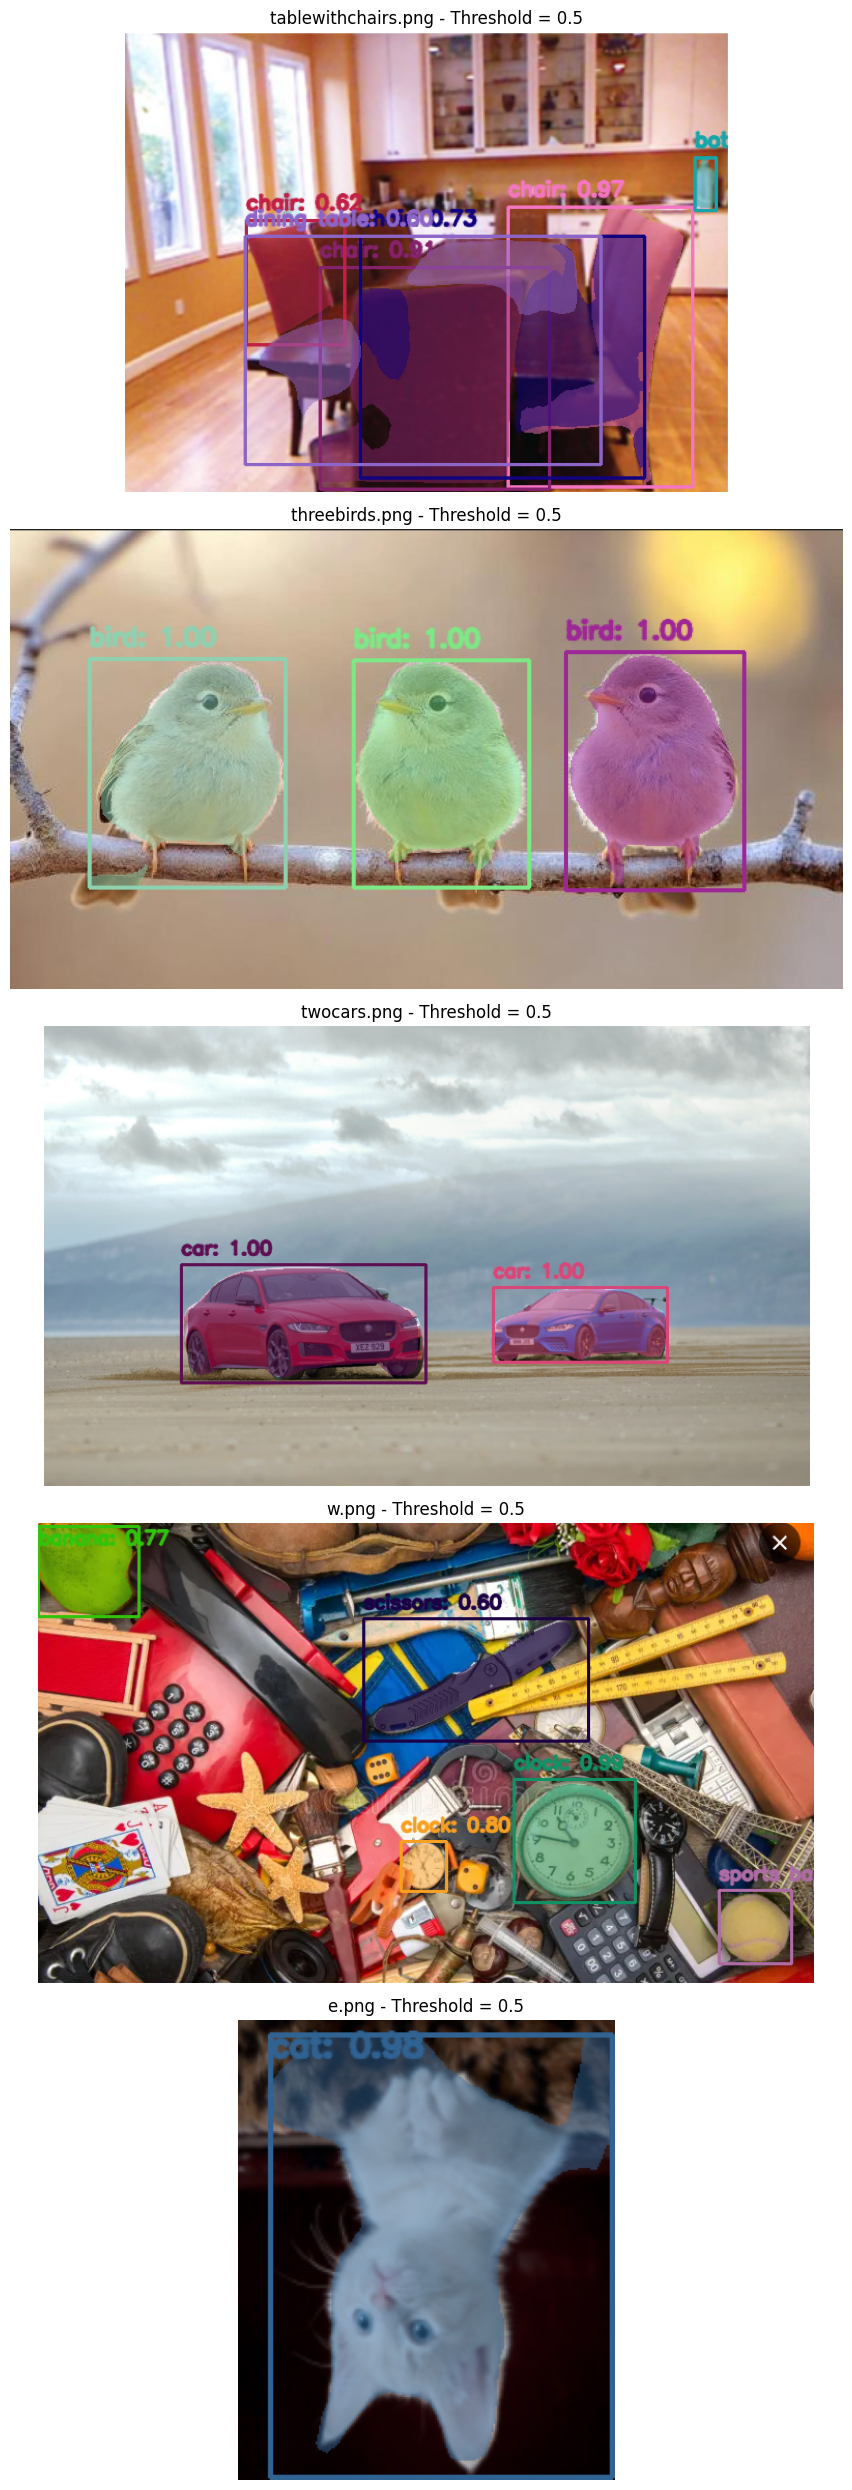

In [22]:
plt.figure(figsize=(18, 25))

for idx, path in enumerate(image_paths):
    image_np = all_results[path]["image"]
    results = all_results[path]["results"]

    vis = visualize_predictions(image_np, results, score_threshold=0.5)

    plt.subplot(len(image_paths), 1, idx + 1)
    plt.imshow(vis)
    plt.title(f"{os.path.basename(path)} - Threshold = 0.5")
    plt.axis("off")

plt.tight_layout()
plt.show()

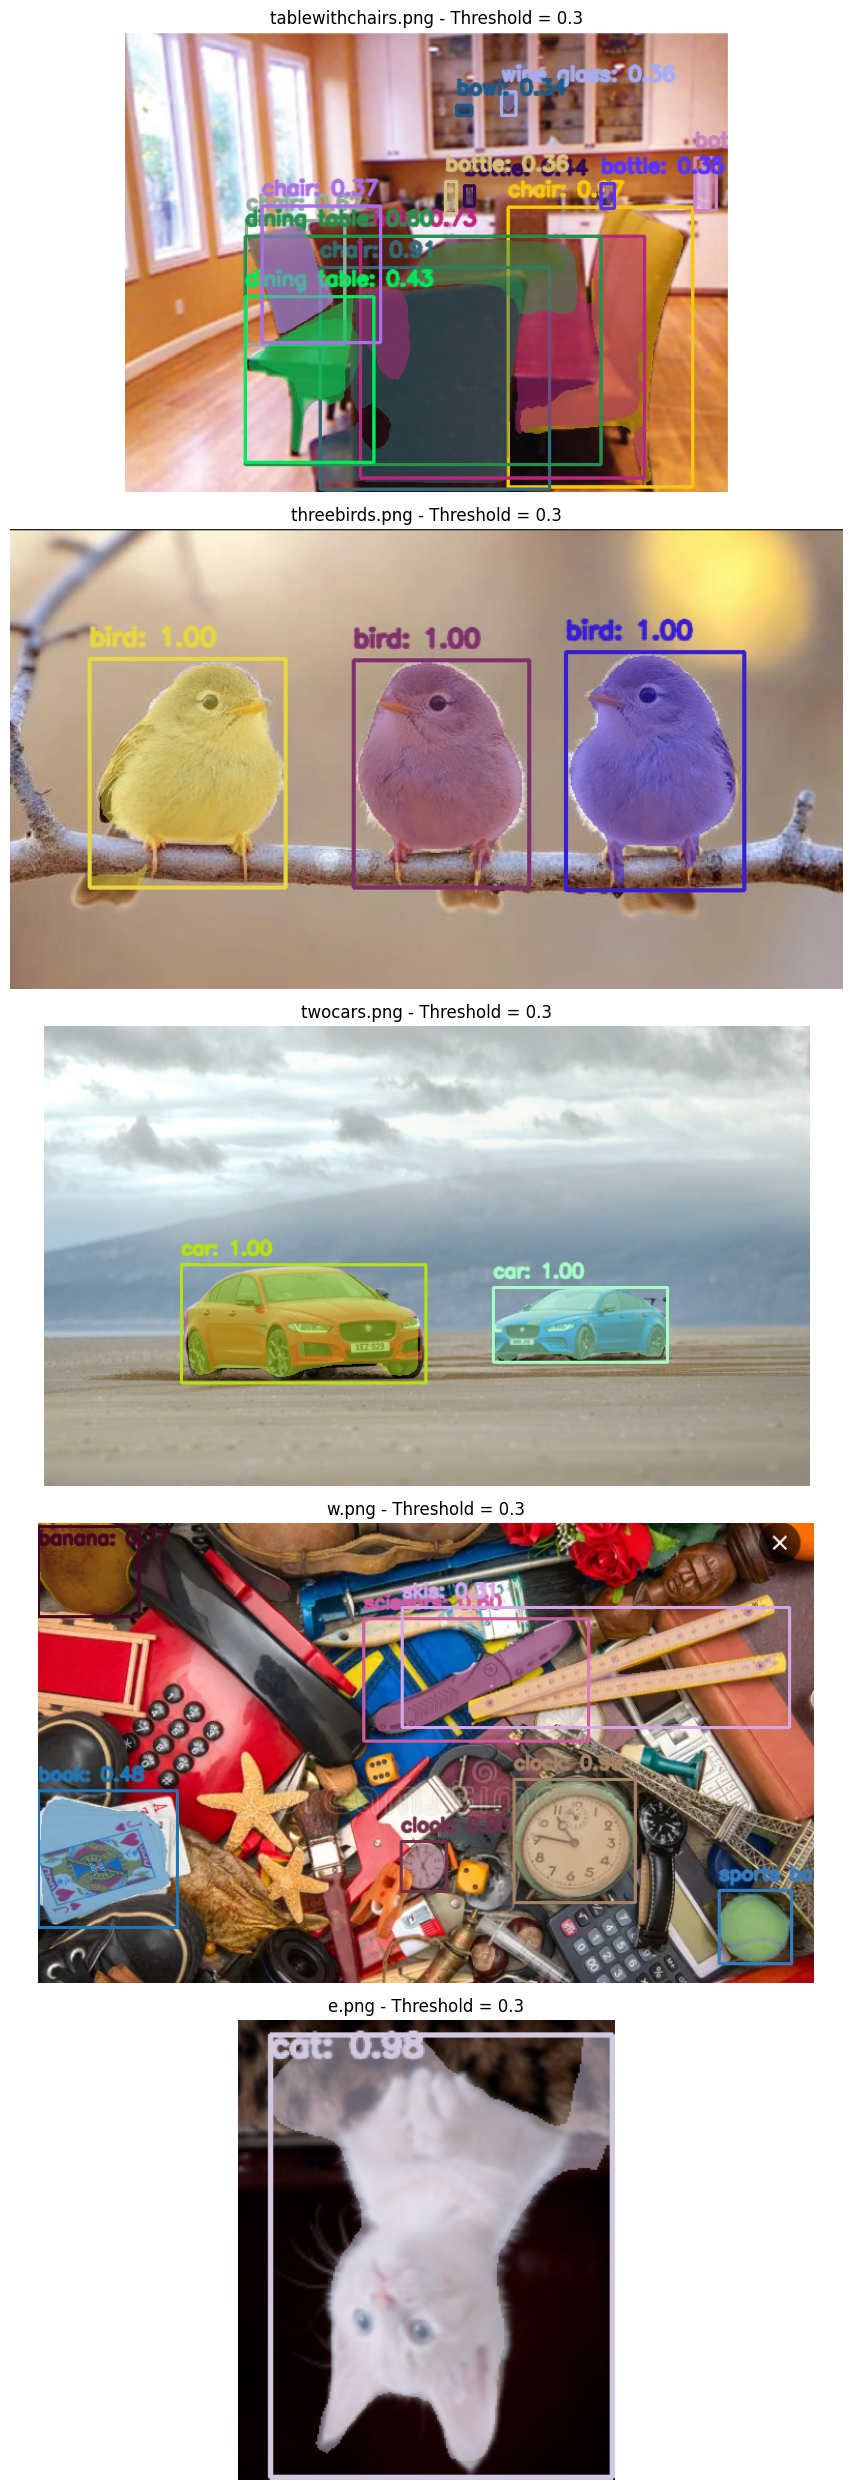

In [23]:
plt.figure(figsize=(18, 25))

for idx, path in enumerate(image_paths):
    image_np = all_results[path]["image"]
    results = all_results[path]["results"]

    vis = visualize_predictions(image_np, results, score_threshold=0.3)

    plt.subplot(len(image_paths), 1, idx + 1)
    plt.imshow(vis)
    plt.title(f"{os.path.basename(path)} - Threshold = 0.3")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
for path in image_paths:
    results = all_results[path]["results"]

    det_05 = extract_predictions(results, score_threshold=0.5)
    det_03 = extract_predictions(results, score_threshold=0.3)

    print(f"\nImage: {os.path.basename(path)}")
    print(f"  Detections @ 0.5 = {len(det_05)}")
    print(f"  Detections @ 0.3 = {len(det_03)}")


Image: tablewithchairs.png
  Detections @ 0.5 = 6
  Detections @ 0.3 = 13

Image: threebirds.png
  Detections @ 0.5 = 3
  Detections @ 0.3 = 3

Image: twocars.png
  Detections @ 0.5 = 2
  Detections @ 0.3 = 2

Image: w.png
  Detections @ 0.5 = 5
  Detections @ 0.3 = 7

Image: e.png
  Detections @ 0.5 = 1
  Detections @ 0.3 = 1
